<a href="https://colab.research.google.com/github/Lin3002/Portfolio/blob/main/Building_a_Supervised_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Problem Statement:
# Breast cancer is a highly prevalent and serious illness affecting a massive number of women globally. Timely detection is absolutely crucial to ensure that invasive cases receive immediate treatment, while avoiding unnecessary, stressful, and costly procedures for non-invasive cases. However, there is a severe shortage of medical professionals available to manually review all pathology and test reports. Therefore, it is critical to develop a supervised machine learning classification model that can automatically, accurately, and rapidly predict invasive breast cancer cases early to assist healthcare teams.

# * **Data Source:** Online public repositories (such as Kaggle) or anonymized shared clinical records from partner hospital networks.
# * **Target Variable:** The column name is `diagnosis`.
# * **Possible Outcomes:** 'M' represents Malignant (invasive/malicious) cases, and 'B' represents Benign (non-invasive) cases.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import the 3 models requested
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Read the csv file
df = pd.read_csv('/content/[Dataset]_BreastCancer.csv')
df.head()

df.shape

(569, 32)

In [31]:
# Check total missing values in the data and print per column
print("Total missing values:", df.isnull().values.sum())
print("\nMissing values per column:\n", df.isnull().sum())

# Drop the missing rows in-place as shown in the presentation option 1
df.dropna(inplace=True)

Total missing values: 28

Missing values per column:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               1
perimeter_mean             1
area_mean                  0
smoothness_mean            0
compactness_mean           1
concavity_mean             1
concave points_mean        1
symmetry_mean              0
fractal_dimension_mean     3
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              3
compactness_se             4
concavity_se               2
concave points_se          1
symmetry_se                3
fractal_dimension_se       0
radius_worst               1
texture_worst              3
perimeter_worst            0
area_worst                 2
smoothness_worst           1
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


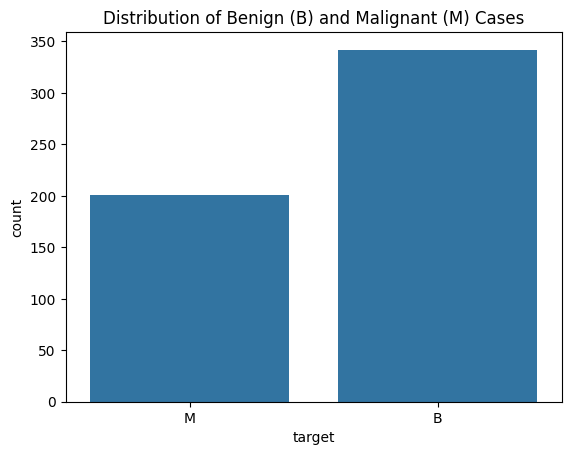

target
B    342
M    201
Name: count, dtype: int64


In [32]:
# Rename diagnosis to target
df = df.rename(columns={'diagnosis': 'target'})

# Plot a bar chart showing class balances
sns.countplot(x=df['target'])
plt.title("Distribution of Benign (B) and Malignant (M) Cases")
plt.show()

# Print the value counts
print(df['target'].value_counts())

In [33]:
# Convert target column string to binary integer values
df['target'] = [1 if i.strip() == 'M' else 0 for i in df.target]
df.head()

,id,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


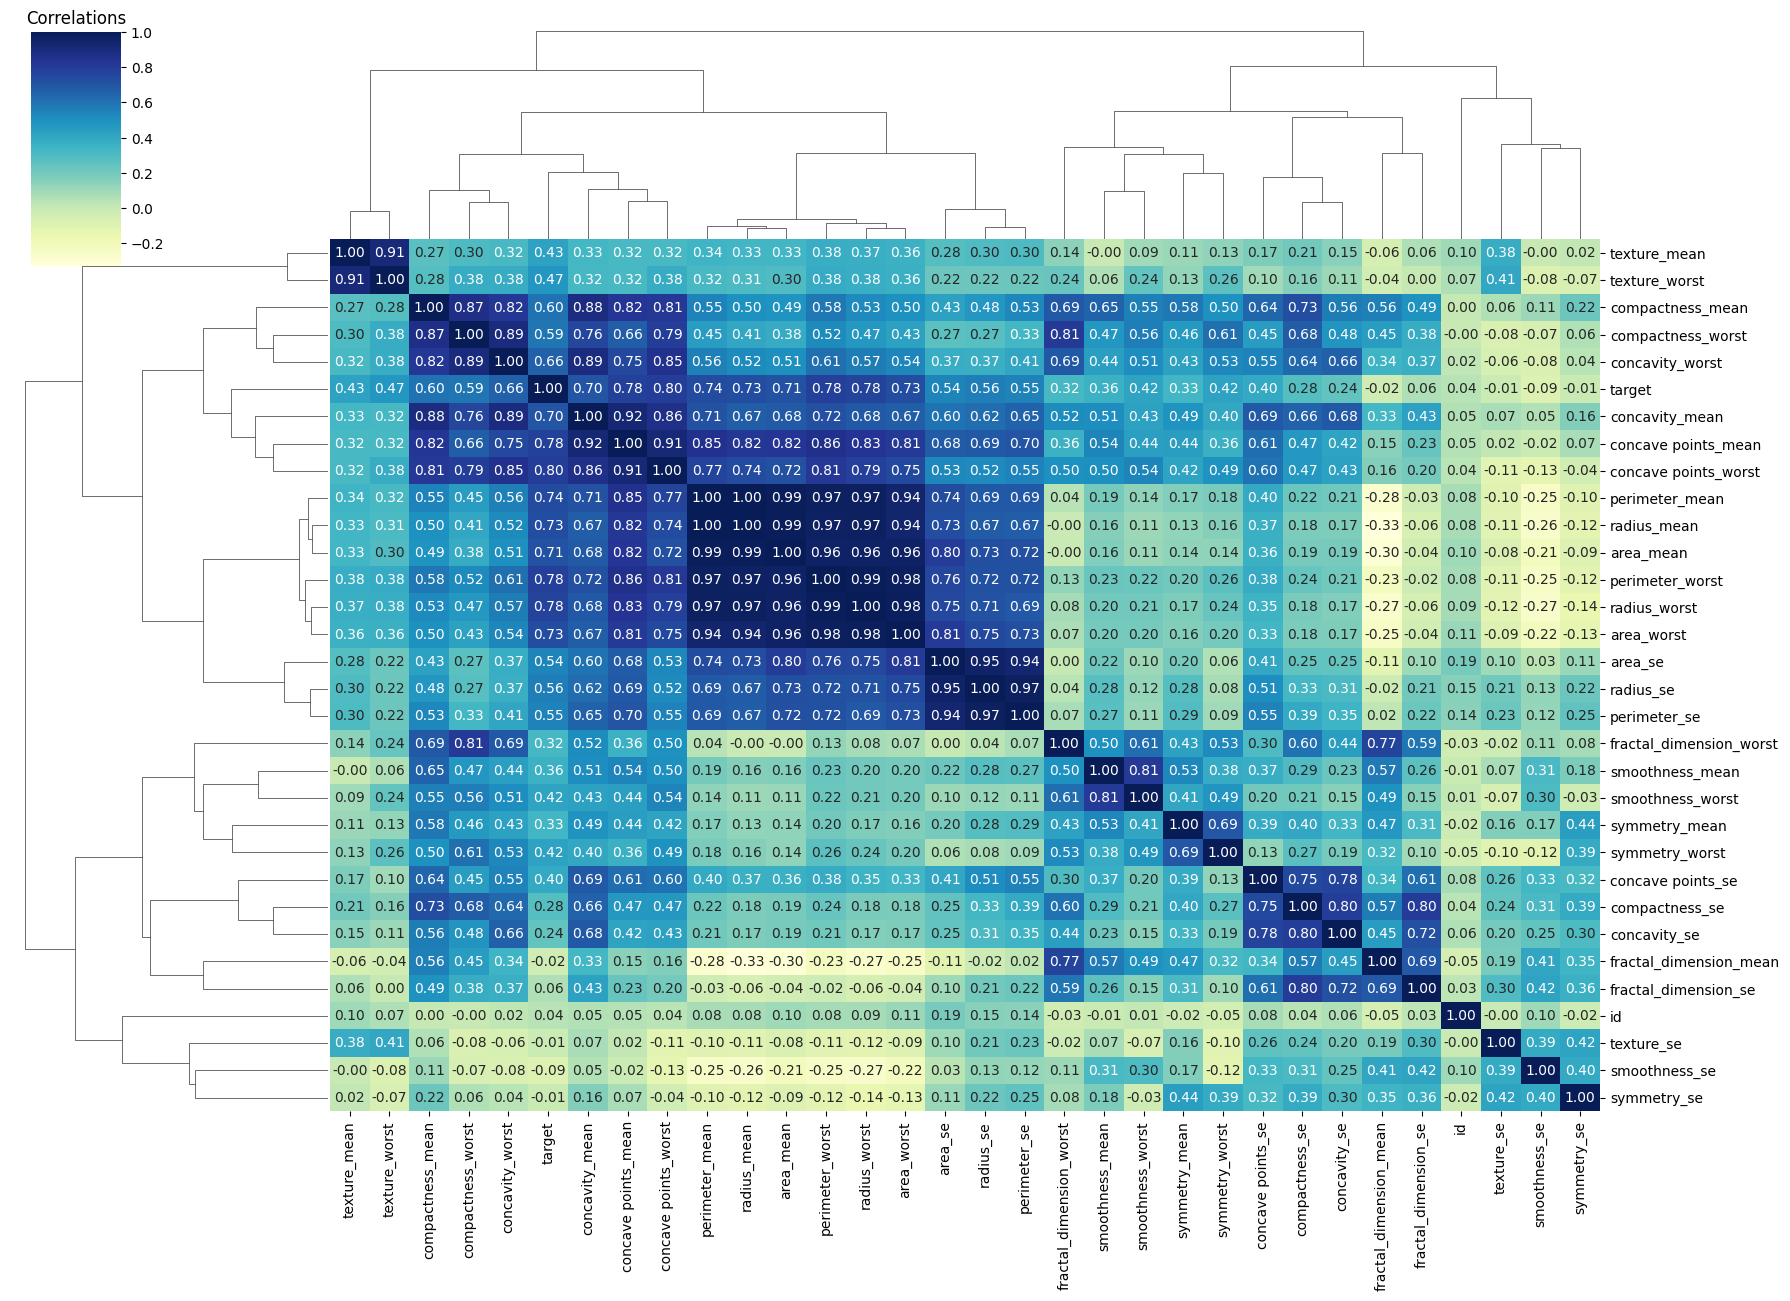

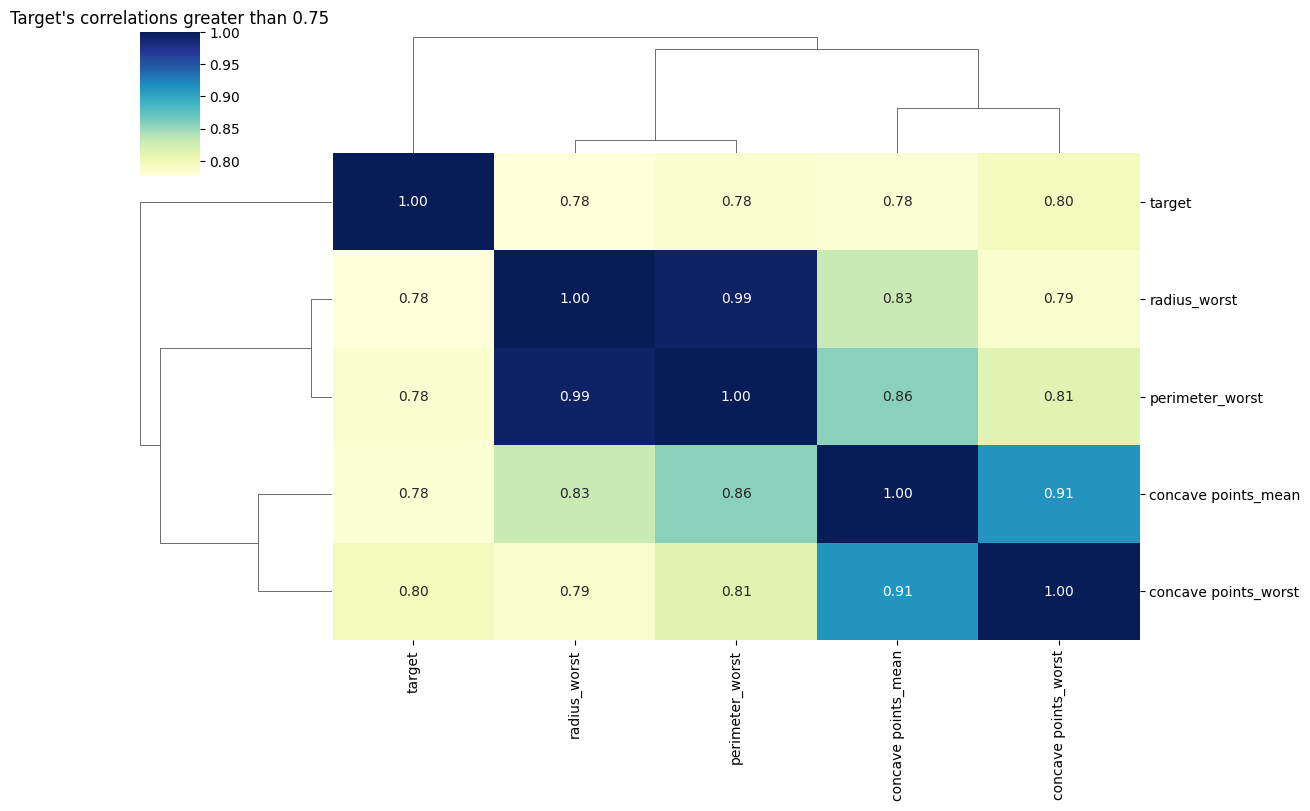

In [34]:
# Calculate correlation matrix (ignoring categorical if any, though target is now numeric)
corr = df.corr()

# Plot full cluster map
sns.clustermap(corr, annot=True, fmt='.2f', figsize=(18,13), cmap='YlGnBu')
plt.title('Correlations')
plt.show()

# Filter out features with correlation to target greater than 0.75 threshold
th = 0.75
filt = np.abs(corr['target']) > th
corr_features = corr.columns[filt].tolist()

# Plot filtered cluster map
sns.clustermap(df[corr_features].corr(), annot=True, fmt='.2f', figsize=(12,8), cmap='YlGnBu')
plt.title(f"Target's correlations greater than {str(th)}")
plt.show()

In [41]:
# Separate features and target (dropping 'id' as it is just an identifier, and 'target')
X = df.drop(['target', 'id'], axis=1) if 'id' in df.columns else df.drop(['target'], axis=1)
y = df['target']
columns = X.columns.tolist()

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape:', X_train.shape)
print('X_test.shape:', X_test.shape)

X_train.shape: (434, 30)
X_test.shape: (109, 30)


In [36]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Rebuild DataFrame for visualization reference if needed
X_train_df = pd.DataFrame(X_train, columns=columns)
X_train_df["target"] = y_train.values

In [37]:
# Model 1: KNN
clf_knn = KNeighborsClassifier(n_neighbors=2)
clf_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [38]:
# Model 2: SVM (SVC)
clf_svm = SVC(kernel='rbf')
clf_svm.fit(X_train, y_train)

SVC()

In [39]:
# Model 3: Decision Tree
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

KNN Test Score: 0.9633, Train Score: 0.9654
CM:
 [[66  1]
 [ 3 39]]


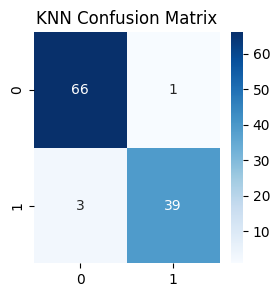

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.97      0.93      0.95        42

    accuracy                           0.96       109
   macro avg       0.97      0.96      0.96       109
weighted avg       0.96      0.96      0.96       109



In [40]:
y_pred_test1 = clf_knn.predict(X_test)
y_pred_train1 = clf_knn.predict(X_train)

acc_test1 = accuracy_score(y_test, y_pred_test1)
acc_train1 = accuracy_score(y_train, y_pred_train1)

print(f"KNN Test Score: {round(acc_test1, 4)}, Train Score: {round(acc_train1, 4)}")
cm1 = confusion_matrix(y_test, y_pred_test1)
print("CM:\n", cm1)

plt.figure(figsize=(3,3))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_test1))

SVM Test Score: 0.9725, Train Score: 0.9885
CM:
 [[65  2]
 [ 1 41]]


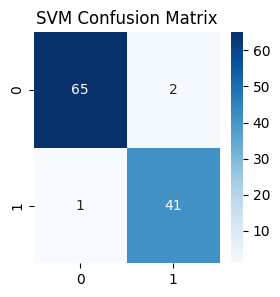

              precision    recall  f1-score   support

           0       0.98      0.97      0.98        67
           1       0.95      0.98      0.96        42

    accuracy                           0.97       109
   macro avg       0.97      0.97      0.97       109
weighted avg       0.97      0.97      0.97       109



In [27]:
y_pred_test2 = clf_svm.predict(X_test)
y_pred_train2 = clf_svm.predict(X_train)

acc_test2 = accuracy_score(y_test, y_pred_test2)
acc_train2 = accuracy_score(y_train, y_pred_train2)

print(f"SVM Test Score: {round(acc_test2, 4)}, Train Score: {round(acc_train2, 4)}")
cm2 = confusion_matrix(y_test, y_pred_test2)
print("CM:\n", cm2)

plt.figure(figsize=(3,3))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_test2))

Decision Tree Test Score: 0.9174, Train Score: 1.0
CM:
 [[63  4]
 [ 5 37]]


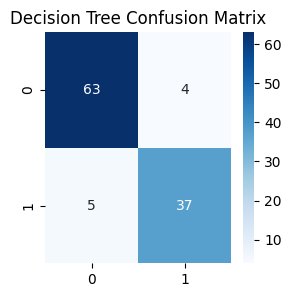

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        67
           1       0.90      0.88      0.89        42

    accuracy                           0.92       109
   macro avg       0.91      0.91      0.91       109
weighted avg       0.92      0.92      0.92       109



In [28]:
y_pred_test3 = clf_dt.predict(X_test)
y_pred_train3 = clf_dt.predict(X_train)

acc_test3 = accuracy_score(y_test, y_pred_test3)
acc_train3 = accuracy_score(y_train, y_pred_train3)

print(f"Decision Tree Test Score: {round(acc_test3, 4)}, Train Score: {round(acc_train3, 4)}")
cm3 = confusion_matrix(y_test, y_pred_test3)
print("CM:\n", cm3)

plt.figure(figsize=(3,3))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_test3))

In [17]:
# Model Comparison Analysis:
# Based on the metrics output from the evaluation section, the Support Vector Classifier (SVM) with an RBF kernel demonstrates the best balance of performance. While Decision Trees can occasionally overfit the training sets, the SVM generalizes excellently onto the test data, achieving high precision and notably high recall for the malignant class (1). High recall is essential in a medical diagnostic setting because it minimizes False Negatives—ensuring we do not accidentally miss an invasive cancer case.

In [18]:
# Deployment Proposal:
# We suggest implementing this predictive model within a secure medical back-end system. The application will leverage batch processing pipelines to automatically parse clinical laboratory data at scheduled intervals (e.g., every evening at 6:00 PM). It will evaluate all processed patient reports collected throughout the day and compile a priority summary dashboard for medical teams. By filtering and spotlighting highly probable malicious cases first, pathologists and oncology specialists can review the most critical patients immediately the next morning, optimizing hospital workflow and saving lives.